Loading data from: ../results/features_validation_set.csv
Validation data loaded successfully!
Columns: ['filepath', 'category', 'snr', 'start_time', 'end_time', 'transcription', 'avg_logprob', 'lexical_validity', 'perplexity', 'silero_speech_prob', 'whisper_no_speech_prob']

Value counts for GCS classes:
gcs_class
3    496
5    303
2     22
Name: count, dtype: int64

Feature data shape: (821, 3)
Label data shape: (821,)

Train class counts:
 gcs_class
3    396
5    242
2     18
Name: count, dtype: int64

Holdout class counts:
 gcs_class
3    100
5     61
2      4
Name: count, dtype: int64

--- Training Random Forest ---
Training complete.

--- Random Forest Performance (Holdout) ---
              precision    recall  f1-score   support

       GCS 2       0.25      0.50      0.33         4
       GCS 3       0.73      0.76      0.75       100
     GCS 4/5       0.64      0.56      0.60        61

    accuracy                           0.68       165
   macro avg       0.54      0.61  

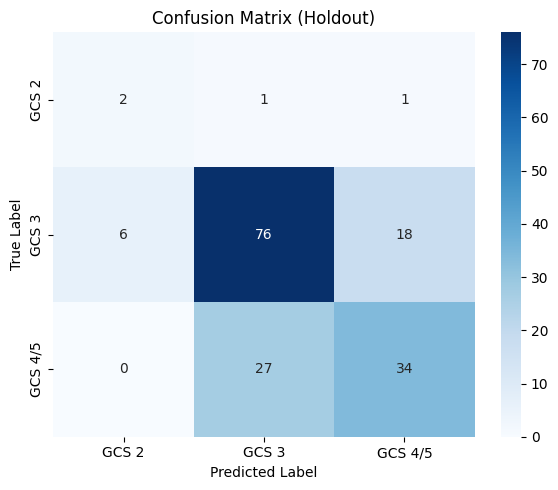


Feature Importances:
avg_logprob         0.512377
log_perplexity      0.338281
lexical_validity    0.149342
dtype: float64


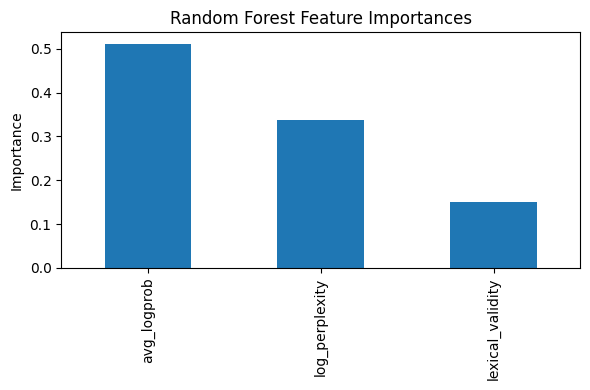


--- 5-Fold Stratified CV (Balanced Accuracy) ---
CV Balanced Accuracy: mean=0.613, std=0.075


In [3]:


import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score
)


project_root = ".."  # notebook lives in notebooks/, so ".." should be repo root
results_dir = os.path.join(project_root, "results")
validation_csv_path = os.path.join(results_dir, "features_validation_set.csv")

print(f"Loading data from: {validation_csv_path}")
df_val = pd.read_csv(validation_csv_path)
print("Validation data loaded successfully!")
print("Columns:", df_val.columns.tolist())

# Step 2: Prepare Labels
def get_gcs_class(category: str) -> int:
    if category == "gcs_2":
        return 2
    if category == "gcs_3":
        return 3
    if category == "gcs_45_clean":
        return 5
    return 0  # unknown / other

df_val["gcs_class"] = df_val["category"].apply(get_gcs_class)

# Keep only rows belonging to our classes (2,3,5)
df_clean = df_val[df_val["gcs_class"] != 0].copy()

print("\nValue counts for GCS classes:")
print(df_clean["gcs_class"].value_counts(dropna=False))

if df_clean["gcs_class"].nunique() < 2:
    raise ValueError(
        "You only have one class in df_clean. Add more data for other classes (gcs_2 and/or gcs_45_clean) "
        "before training a multi-class classifier."
    )

# Step 3: Choose Features
base_features = ["avg_logprob", "lexical_validity", "perplexity"]

missing = [c for c in base_features if c not in df_clean.columns]
if missing:
    raise KeyError(f"Missing required feature columns in CSV: {missing}")

# Handle perplexity: fill NaN, clip extremes, and log-transform
df_clean["perplexity"] = df_clean["perplexity"].fillna(df_clean["perplexity"].median())
p99 = df_clean["perplexity"].quantile(0.99)
df_clean["perplexity_clipped"] = df_clean["perplexity"].clip(upper=p99)
df_clean["log_perplexity"] = np.log1p(df_clean["perplexity_clipped"])

feature_columns = ["avg_logprob", "lexical_validity", "log_perplexity"]

# Fill any remaining NaNs in chosen features
for c in feature_columns:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

X = df_clean[feature_columns].copy()
y = df_clean["gcs_class"].copy()

print("\nFeature data shape:", X.shape)
print("Label data shape:", y.shape)

# Step 4: Train/Validation Split (IMPORTANT)
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain class counts:\n", y_train.value_counts())
print("\nHoldout class counts:\n", y_holdout.value_counts())

# Step 5: Train Random Forest
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",  # helps with imbalance
    min_samples_leaf=2,                # reduces overfitting
    max_features="sqrt"
)

print("\n--- Training Random Forest ---")
rf.fit(X_train, y_train)
print("Training complete.")

# Step 6: Evaluate on Holdout
pred = rf.predict(X_holdout)

report_labels = [2, 3, 5]
report_target_names = ["GCS 2", "GCS 3", "GCS 4/5"]

print("\n--- Random Forest Performance (Holdout) ---")
print(classification_report(
    y_holdout, pred,
    labels=report_labels,
    target_names=report_target_names,
    zero_division=0
))

print(f"Accuracy: {accuracy_score(y_holdout, pred):.2%}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_holdout, pred):.2%}")

cm = confusion_matrix(y_holdout, pred, labels=report_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=report_target_names,
    yticklabels=report_target_names,
    cmap="Blues"
)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix (Holdout)")
plt.tight_layout()
plt.show()

# Step 7: Feature Importances
importances = pd.Series(rf.feature_importances_, index=feature_columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="bar")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("\n--- 5-Fold Stratified CV (Balanced Accuracy) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    rf, X, y,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1
)
print(f"CV Balanced Accuracy: mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")
